In [6]:
import pandas as pd
import duckdb

In [7]:
con = duckdb.connect('fraud.db')

con.execute("CREATE TABLE transactions AS SELECT * FROM read_csv_auto('transactions.csv')")
con.execute("CREATE TABLE pca_features_a AS SELECT * FROM read_csv_auto('pca_features_a.csv')")
con.execute("CREATE TABLE pca_features_b AS SELECT * FROM read_csv_auto('pca_features_b.csv')")
con.execute("CREATE TABLE fraud_labels AS SELECT * FROM read_csv_auto('fraud_labels.csv')")

print(con.execute("SELECT * FROM transactions LIMIT 5").df())

   transaction_id  Time  Amount
0               0   0.0  149.62
1               1   0.0    2.69
2               2   1.0  378.66
3               3   1.0  123.50
4               4   2.0   69.99


In [8]:
full_data = con.execute("""
    SELECT t.transaction_id, t.Time, t.Amount,
           a.V1, a.V2, a.V3, a.V4, a.V5, a.V6, a.V7, a.V8, a.V9, a.V10, a.V11, a.V12, a.V13, a.V14,
           b.V15, b.V16, b.V17, b.V18, b.V19, b.V20, b.V21, b.V22, b.V23, b.V24, b.V25, b.V26, b.V27, b.V28,
           f.Class
    FROM transactions t
    JOIN pca_features_a a ON t.transaction_id = a.transaction_id
    JOIN pca_features_b b ON t.transaction_id = b.transaction_id
    JOIN fraud_labels f ON t.transaction_id = f.transaction_id
""").df()

# checking class imbalance
print(con.execute("""
    SELECT Class, COUNT(*) as count
    FROM fraud_labels
    GROUP BY Class
""").df())

# checking average transaction amount by fraud class
print(con.execute("""
    SELECT f.Class, AVG(t.Amount) as avg_amount
    FROM transactions t
    JOIN fraud_labels f ON t.transaction_id = f.transaction_id
    GROUP BY f.Class
""").df())

   Class   count
0      0  284315
1      1     492
   Class  avg_amount
0      0   88.291022
1      1  122.211321


### Simple logistic regression before applying SMOTE (synthetic data creation) to the dataset

c:\Users\jiaro\Downloads\DS4320_project1\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


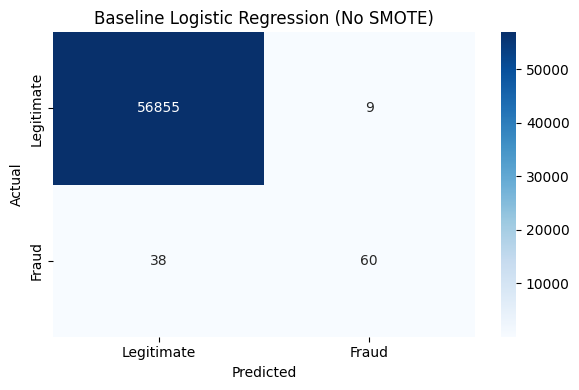

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# set up logging
logging.basicConfig(filename='pipeline.log', level=logging.INFO)
logger = logging.getLogger(__name__)


logger.info("starting baseline logistic regression")

# separate features and target
X = full_data.drop(columns=['transaction_id', 'Class'])
y = full_data['Class']

# train/test split - stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
logger.info(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

# fit logistic regression
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train, y_train)
logger.info("baseline logistic regression fitted")

# predictions
y_pred_baseline = lr_baseline.predict(X_test)

# confusion matrix
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

# plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Baseline Logistic Regression (No SMOTE)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=300)
plt.show()

The baseline logistic regression model was trained on the original dataset without any adjustments for class imbalance. While it only incorrectly flagged 9 legitimate transactions as fraud, it missed 38 out of 98 actual fraudulent transactions. This happened because the dataset is so heavily skewed toward legitimate transactions that the model never really learned what fraud looks like. It essentially got too comfortable predicting that everything was legitimate, which is not acceptable for a real fraud detection system.

Next we will perform logistic regression with SMOTE to try and minimize the effects of the class imbalance. 

c:\Users\jiaro\Downloads\DS4320_project1\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


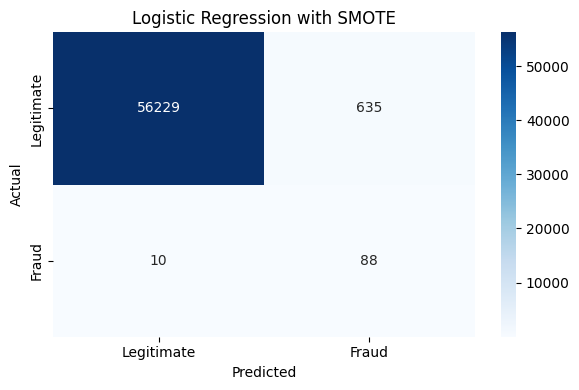

Logistic Regression with SMOTE Results:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56864
       Fraud       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [ ]:
from imblearn.over_sampling import SMOTE



logger.info("starting logistic regression with SMOTE")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

logger.info(f"After SMOTE - Class counts: {pd.Series(y_train_smote).value_counts().to_dict()}")

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
logger.info("SMOTE logistic regression fitted")

y_pred_smote = lr_smote.predict(X_test)

cm_smote = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Logistic Regression with SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_smote_lr.png', dpi=300)
plt.show()


logger.info("logistic regression with SMOTE complete")

We can see that SMOTE significantly improved fraud recall, catching 88 out of 98 fraudulent transactions compared to only 60 in the baseline. However, this came at the cost of increased false positives, rising from 9 to 635. This tradeoff motivates the use of more complex models in the following steps. First, XGBoost

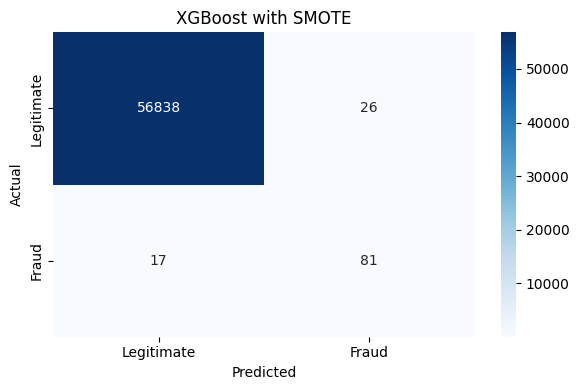

XGBoost with SMOTE Results:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.76      0.83      0.79        98

    accuracy                           1.00     56962
   macro avg       0.88      0.91      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
from xgboost import XGBClassifier

logger.info("starting XGBoost with SMOTE")

# fit xgboost on SMOTE training data
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train_smote, y_train_smote)
logger.info("XGBoost fitted")

# predictions
y_pred_xgb = xgb.predict(X_test)

# plot confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('XGBoost with SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_smote_xgb.png', dpi=300)
plt.show()


logger.info("xgboost with SMOTE complete")

Across the four models tested, XGBoost with SMOTE produced the most balanced results for this project's goal of reducing false positives while maintaining strong fraud detection. The baseline logistic regression had very few false positives but missed a large portion of fraudulent transactions. Applying SMOTE to logistic regression dramatically improved fraud detection but caused false positives to spike to 635, making it impractical for real world use. XGBoost with SMOTE struck the best balance, catching 81 out of 98 fraudulent transactions while keeping false positives low at just 26, making it the recommended approach for fraud detection systems where customer experience is a priority.

Now we will try with random forest

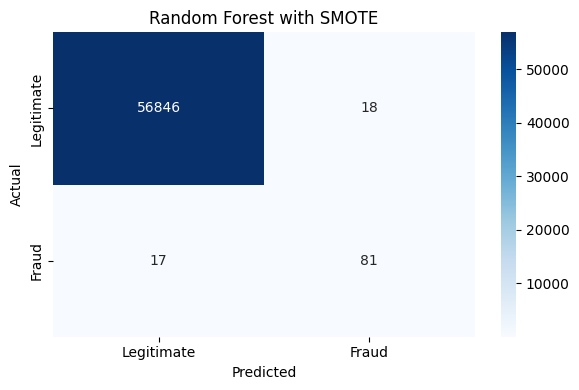

Random Forest with SMOTE Results:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.82      0.83      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
from sklearn.ensemble import RandomForestClassifier

logger.info("starting random forest with SMOTE")

# fit random forest on SMOTE training data
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_smote, y_train_smote)
logger.info("random forest fitted")

# predictions
y_pred_rf = rf.predict(X_test)

# plot confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Random Forest with SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_smote_rf.png', dpi=300)
plt.show()


logger.info("random forest with SMOTE complete")

The Random Forest model trained on SMOTE resampled data produced the best overall results for this project's goal of minimizing false positives. It correctly identified 81 out of 98 fraudulent transactions while only incorrectly flagging 18 legitimate transactions as fraud. This is a significant improvement over both the SMOTE logistic regression model, which had 635 false positives, and the XGBoost model, which had 26. 

Now to explore different thresholds on the random forest model!

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

logger.info("starting threshold tuning on random forest")

# get predicted probabilities instead of hard predictions
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# test a range of thresholds
thresholds = np.arange(0.1, 0.9, 0.05)

results = []
for threshold in thresholds:
    y_pred_thresh = (y_prob_rf >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    results.append({
        'threshold': round(threshold, 2),
        'true_negatives': tn,
        'false_positives': fp,
        'false_negatives': fn,
        'true_positives': tp,
        'precision': round(precision_score(y_test, y_pred_thresh, zero_division=0), 3),
        'recall': round(recall_score(y_test, y_pred_thresh), 3),
        'f1': round(f1_score(y_test, y_pred_thresh), 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# plot false positives and true positives across thresholds
plt.figure(figsize=(10, 5))
plt.plot(results_df['threshold'], results_df['false_positives'], 
         label='False Positives', color='red')
plt.plot(results_df['threshold'], results_df['true_positives'], 
         label='True Positives', color='green')
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('False Positives vs True Positives Across Thresholds')
plt.legend()
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=300)
plt.show()

logger.info("threshold tuning on Random Forest complete")